In [2]:
import seaborn as sns
sns.set_style("darkgrid")
import json
import numpy as np
import os

In [3]:
data_set = "breast_cancer"
bias_type = "mean_difference"
path = f"../results/budget_comparison/{data_set}/{bias_type}/fw-sampling-mrs/"
number_of_files = len([name for name in os.listdir(path)]) - 1
auroc_list = []
mean_auroc_dict = {}
for i in range(number_of_files):
    with open(path + f"aurocs_{i}.json") as file:
        auroc_with_feature_weights = json.load(file)
        auroc_list.append(auroc_with_feature_weights)
for budget in auroc_with_feature_weights:
    budget_aurocs = []
    for i in range(number_of_files ):
        single_budget_auroc = auroc_list[i][budget]
        budget_aurocs.append(single_budget_auroc)
    budget_aurocs = np.array(budget_aurocs)
    mean_auroc_dict[budget] = np.mean(budget_aurocs, axis=0)

NameError: name 'auroc_with_feature_weights' is not defined

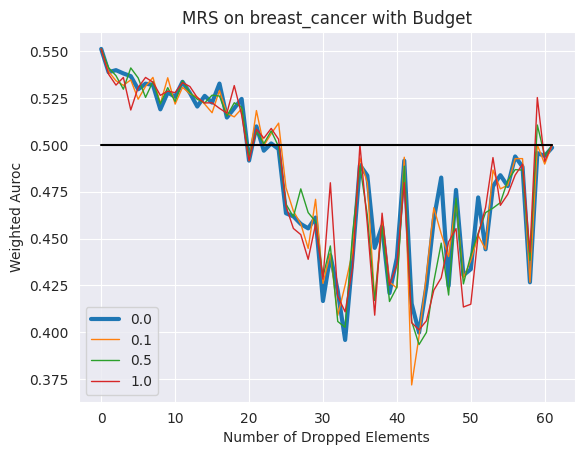

In [ ]:
for budget in mean_auroc_dict:
    if budget == "0.0":
        linewidth = 3
    else: linewidth = 1
    aurocs = mean_auroc_dict[budget]
    ax = sns.lineplot(aurocs[:], label=(str(budget)), linewidth=linewidth)
sns.lineplot([0.5] * len(aurocs[:]), color="black")
ax.set(title=f'MRS on {data_set} with Budget')
_ = ax.set(xlabel='Number of Dropped Elements', ylabel='Weighted Auroc')

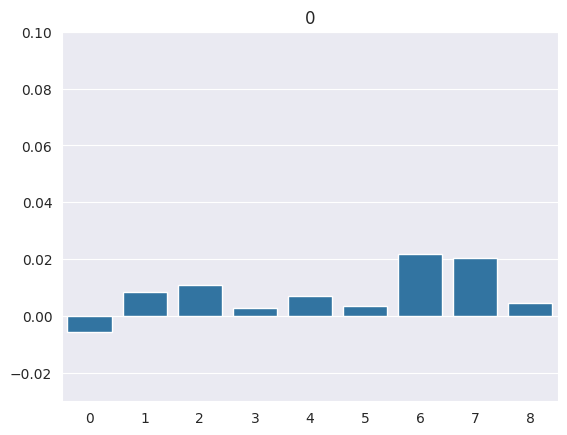

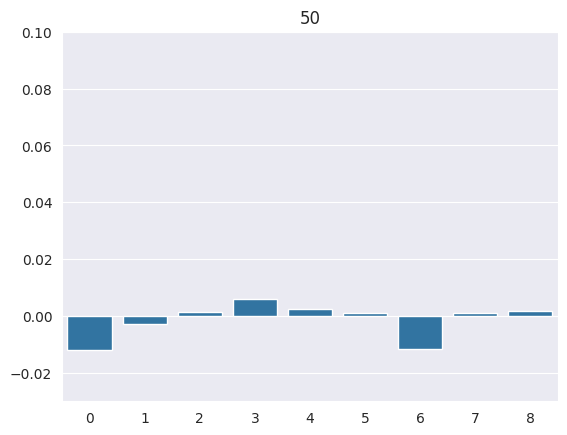

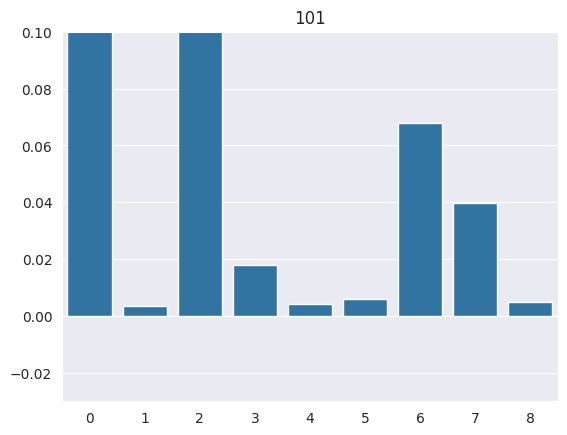

In [ ]:
import matplotlib.pyplot as plt
path = f"../results/budget_comparison/{data_set}/{bias_type}/fw-sampling-mrs/feature_weights/"
number_of_files = len([name for name in os.listdir(path)]) - 1
plot_iterations = np.array([0, 0.5,  1])
plot_iterations = (number_of_files * plot_iterations).astype(int)
for i in plot_iterations:
    with open(path + f"feature_weights_{i}.json") as file:
        feature_imortance = json.load(file)
        ax = sns.barplot(feature_imortance)
        ax.set(title=i)
        ax.set_ylim(-0.03, 0.1)
        plt.show()

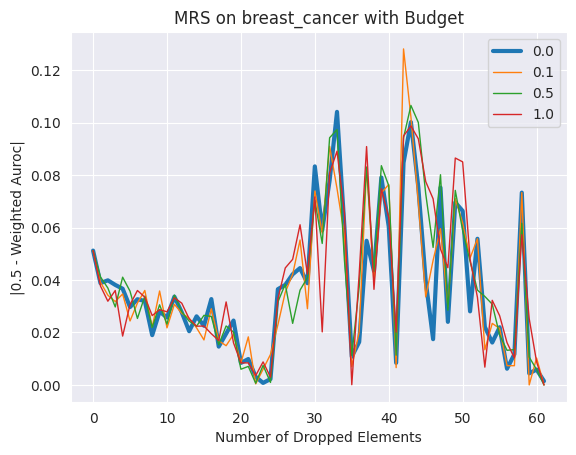

In [ ]:
for budget in mean_auroc_dict:
    if budget == "0.0":
        linewidth = 3
    else: linewidth = 1
    aurocs = mean_auroc_dict[budget]
    aurocs_difference = np.abs(0.5 - np.array(aurocs))
    ax = sns.lineplot(aurocs_difference[:], label=(str(budget)), linewidth=linewidth)
_ = ax.set(title=f'MRS on {data_set} with Budget')
_ = ax.set(xlabel='Number of Dropped Elements', ylabel='|0.5 - Weighted Auroc|')

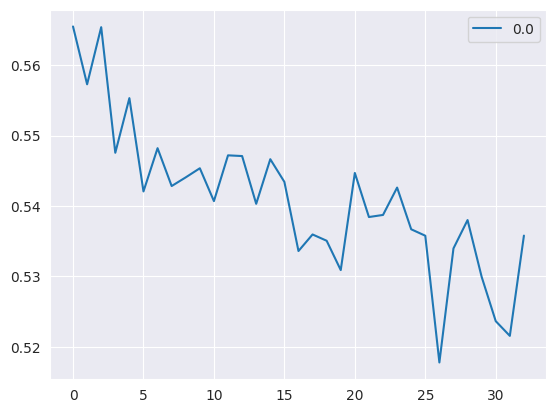

In [11]:
with open(f"../feature_weighted_auroc.json") as file:
    aurocs = json.load(file)
    ax = sns.lineplot(aurocs)